In [ ]:
import requests
import pandas as pd
import os
from time import sleep

def extrair_ifdata_robusto(pasta_destino):
    os.makedirs(pasta_destino, exist_ok=True)
    
    tipo_inst = 1
    relatorios = {
        "1": "Resumo", 
        "2": "Ativo", 
        "3": "Passivo", 
        "4": "Resultado"
    }
    
    anos = range(2014, 2025)
    trimestres = ["03", "06", "09", "12"]
    print(f"Iniciando Extração de Alta Performance: {os.path.abspath(pasta_destino)}")
    print("-" * 60)
    session = requests.Session()
    session.headers.update({"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"})
    for ano in anos:
        for tri in trimestres:
            data_ref = int(f"{ano}{tri}")
            
            for cod_rel, nome_rel in relatorios.items():
                nome_arquivo = f"IFDATA_{data_ref}_{nome_rel}.csv"
                caminho_completo = os.path.join(pasta_destino, nome_arquivo)

                if os.path.exists(caminho_completo):
                    print(f"[PULANDO] {nome_arquivo} já existe.")
                    continue
                
                url = (
                    f"https://olinda.bcb.gov.br/olinda/servico/IFDATA/versao/v1/odata/"
                    f"IfDataValores(AnoMes=@AnoMes,TipoInstituicao=@TipoInstituicao,Relatorio=@Relatorio)"
                    f"?@AnoMes={data_ref}&@TipoInstituicao={tipo_inst}&@Relatorio='{cod_rel}'&$format=json"
                )
                
                sucesso = False
                
                for tentativa in range(1, 4):
                    try:
                        resposta = session.get(url, timeout=120)
                        
                        if resposta.status_code == 200:
                            dados = resposta.json().get('value', [])
                            if dados:
                                df = pd.DataFrame(dados)
                                df.to_csv(caminho_completo, index=False, sep=';', encoding='utf-8-sig')
                                print(f"[OK] Sucesso: {data_ref} - {nome_rel} ({len(df)} linhas)")
                            else:
                                print(f"[-] Vazio: {data_ref} - {nome_rel}")
                                
                            sucesso = True
                            break 
                            
                        else:
                            print(f"[Erro {resposta.status_code}] Tentativa {tentativa}/3 para {nome_rel}_{data_ref}")
                            sleep(3) 
                            
                    except requests.exceptions.ReadTimeout:
                        print(f"[Timeout] BCB lento na tentativa {tentativa}/3 ({nome_rel}_{data_ref}). Retentando...")
                        sleep(5)
                    except requests.exceptions.RequestException as e:
                        print(f"[Falha de Rede] Tentativa {tentativa}/3: {e}")
                        sleep(5)
                
                if not sucesso:
                    print(f"[DESISTÊNCIA] Não foi possível baixar {nome_arquivo}. Tente em outro horário.")
                sleep(0.5)

    print("\nProcesso concluído!")
extrair_ifdata_robusto('./dados_bcb_olinda')

Iniciando Extração de Alta Performance: /home/inovar-para-pessoas-negras/Área de trabalho/gustavo/bank-distress-foretoken/dados_bcb_olinda
------------------------------------------------------------
[-] Vazio: 200503 - Resumo
[-] Vazio: 200503 - Ativo
[-] Vazio: 200503 - Passivo
[-] Vazio: 200503 - Resultado


KeyboardInterrupt: 

In [ ]:
import pandas as pd
import glob
import os

def processar_e_unir_ifdata(pasta_dados):
    print("Iniciando a leitura de todos os arquivos...")
    
    arquivos = glob.glob(os.path.join(pasta_dados, "IFDATA_*.csv"))
    
    if not arquivos:
        print("Nenhum arquivo encontrado na pasta.")
        return None

    lista_dfs = []
    for arquivo in arquivos:
        print(f"Lendo: {os.path.basename(arquivo)}")
        df = pd.read_csv(arquivo, sep=';', dtype={'CodInst': str, 'AnoMes': str})
        lista_dfs.append(df)

    print("\nEmpilhando os dados (Concatenando)...")
    df_completo = pd.concat(lista_dfs, ignore_index=True)
    print("Limpando e estruturando os nomes das contas contábeis...")
    if 'NomeColuna' in df_completo.columns:
        df_completo['NomeColuna'] = df_completo['NomeColuna'].str.replace('\n', ' ', regex=False)
        df_completo['NomeColuna'] = df_completo['NomeColuna'].str.replace(r'\s+', ' ', regex=True).str.strip()
        
        if 'NomeRelatorio' in df_completo.columns:
            df_completo['NomeColuna'] = df_completo['NomeRelatorio'] + " - " + df_completo['NomeColuna']

    print("Girando a tabela para o formato de Inteligência Artificial (Pivot)...")
    df_mestre = df_completo.pivot_table(
        index=['CodInst', 'AnoMes'], 
        columns='NomeColuna', 
        values='Saldo', 
        aggfunc='first'
    ).reset_index()
    df_mestre = df_mestre.fillna(0)
    caminho_saida = os.path.join(pasta_dados, "DATASET_MESTRE_IA.csv")
    df_mestre.to_csv(caminho_saida, index=False, sep=';', encoding='utf-8-sig')
    
    print("-" * 60)
    print(f"SUCESSO! Tabela final criada com {df_mestre.shape[0]} registros e {df_mestre.shape[1]} colunas contábeis.")
    print(f"Arquivo salvo em: {caminho_saida}")
    
    return df_mestre
dataset_final = processar_e_unir_ifdata('./dados_bcb_olinda')

Iniciando a leitura de todos os arquivos...
Lendo: IFDATA_202103_Passivo.csv
Lendo: IFDATA_202212_Resultado.csv
Lendo: IFDATA_201903_Ativo.csv
Lendo: IFDATA_202012_Resumo.csv
Lendo: IFDATA_202403_Resumo.csv
Lendo: IFDATA_201506_Ativo.csv
Lendo: IFDATA_202403_Resultado.csv
Lendo: IFDATA_202312_Resultado.csv
Lendo: IFDATA_202406_Passivo.csv
Lendo: IFDATA_202309_Resumo.csv
Lendo: IFDATA_201909_Ativo.csv
Lendo: IFDATA_201603_Passivo.csv
Lendo: IFDATA_201406_Resumo.csv
Lendo: IFDATA_201809_Resultado.csv
Lendo: IFDATA_202006_Resultado.csv
Lendo: IFDATA_201809_Resumo.csv
Lendo: IFDATA_202206_Resultado.csv
Lendo: IFDATA_202409_Ativo.csv
Lendo: IFDATA_201709_Ativo.csv
Lendo: IFDATA_201503_Ativo.csv
Lendo: IFDATA_201909_Resumo.csv
Lendo: IFDATA_201612_Ativo.csv
Lendo: IFDATA_201709_Passivo.csv
Lendo: IFDATA_202412_Ativo.csv
Lendo: IFDATA_201512_Resultado.csv
Lendo: IFDATA_202106_Ativo.csv
Lendo: IFDATA_202103_Ativo.csv
Lendo: IFDATA_202409_Passivo.csv
Lendo: IFDATA_201412_Passivo.csv
Lendo: IFDA

In [ ]:
import pandas as pd
import os

def aplicar_gabarito_falencias(caminho_dados_ifdata, caminho_dados_regesp):
    print("1. Carregando a lista oficial de falências (Regesp)...")
    df_regesp = pd.read_csv(caminho_dados_regesp, sep=';', dtype={'Cnpj': str}, encoding='utf-8', on_bad_lines='skip')
    df_regesp['Cnpj'] = df_regesp['Cnpj'].str.zfill(14)
    df_regesp['CodInst'] = df_regesp['Cnpj'].str[:8]
    df_regesp['DataInicioRegime'] = pd.to_datetime(df_regesp['DataInicioRegime'], errors='coerce')
    df_regesp = df_regesp.dropna(subset=['DataInicioRegime']) 
    df_regesp['AnoMes_Quebra'] = df_regesp['DataInicioRegime'].dt.strftime('%Y%m').astype(int)
    df_regesp = df_regesp[df_regesp['AnoMes_Quebra'] >= 201400]
    print(f" -> Encontrados {len(df_regesp)} registros de regimes especiais de 2014 para cá.")
    print("\n2. Carregando o Dataset Mestre Histórico (IFDATA)...")
    df_mestre = pd.read_csv(caminho_dados_ifdata, sep=';', dtype={'CodInst': str, 'AnoMes': int})
    df_mestre['Falencia_Target'] = 0
    
    print("\n3. Cruzando os dados e aplicando os rótulos de risco...")
    bancos_afetados = 0
    
    for _, linha in df_regesp.iterrows():
        codigo = linha['CodInst']
        data_quebra = linha['AnoMes_Quebra']
        nome_banco = linha['NomeIf']
        if codigo in df_mestre['CodInst'].values:
            bancos_afetados += 1
            mascara_risco = (df_mestre['CodInst'] == codigo) & (df_mestre['AnoMes'] <= data_quebra)
            df_mestre.loc[mascara_risco, 'Falencia_Target'] = 1
            
            print(f" [+] Marcado: {nome_banco[:30]}... (Quebrou em {data_quebra})")

    # 4. Salvar o resultado
    caminho_saida = caminho_dados_ifdata.replace('.csv', '_ROTULADO.csv')
    df_mestre.to_csv(caminho_saida, index=False, sep=';', encoding='utf-8-sig')
    
    print("-" * 60)
    print("RESUMO DA ROTULAÇÃO:")
    print(f"Total de Instituições falidas encontradas no IFDATA: {bancos_afetados}")
    print(f"Linhas Saudáveis (0): {len(df_mestre[df_mestre['Falencia_Target'] == 0])}")
    print(f"Linhas com Doença/Falência (1): {len(df_mestre[df_mestre['Falencia_Target'] == 1])}")
    print(f"\nArquivo final pronto para a IA salvo em: {caminho_saida}")
caminho_ifdata = './dados_bcb_olinda/DATASET_MESTRE_IA.csv'
caminho_regesp = './Regesp_Internet_Exportar-1.csv' 

aplicar_gabarito_falencias(caminho_ifdata, caminho_regesp)

1. Carregando a lista oficial de falências (Regesp)...
 -> Encontrados 59 registros de regimes especiais de 2014 para cá.

2. Carregando o Dataset Mestre Histórico (IFDATA)...

3. Cruzando os dados e aplicando os rótulos de risco...
 [+] Marcado: COOPERATIVA DE CREDITO RURAL H... (Quebrou em 201703)
 [+] Marcado: COOPERATIVA DE CRÉDITO MÚTUO D... (Quebrou em 201801)
 [+] Marcado: COOPERATIVA DE CRÉDITO RURAL C... (Quebrou em 201809)
 [+] Marcado: COOPERATIVA DE ECONOMIA E CRÉD... (Quebrou em 202302)
 [+] Marcado: WILL FINANCEIRA S.A. CRÉDITO, ... (Quebrou em 202601)
------------------------------------------------------------
RESUMO DA ROTULAÇÃO:
Total de Instituições falidas encontradas no IFDATA: 5
Linhas Saudáveis (0): 61019
Linhas com Doença/Falência (1): 84

Arquivo final pronto para a IA salvo em: ./dados_bcb_olinda/DATASET_MESTRE_IA_ROTULADO.csv


Etapa dois: Nós dos Grafo

In [ ]:
import pandas as pd
import numpy as np
import glob
import os
from sklearn.preprocessing import StandardScaler

def criar_matriz_gnn_robusta(pasta_dados):
    print("1. A iniciar o Pipeline de Processamento para GNN...")
    todos_ficheiros = glob.glob(os.path.join(pasta_dados, "IFDATA_*.csv"))
    
    if not todos_ficheiros:
        print("Erro: Nenhum ficheiro encontrado. Verifique o nome da pasta!")
        return
    
    lista_dfs = []

    print(f"2. A ler e a limpar {len(todos_ficheiros)} ficheiros temporais...")
    for ficheiro in todos_ficheiros:
        try:
            nome_base = os.path.basename(ficheiro).replace(".csv", "")
            partes = nome_base.split("_")
            if len(partes) < 3: continue
                
            relatorio = partes[2] 
            df = pd.read_csv(ficheiro, sep=';', dtype=str)
            df.columns = [c.lower() for c in df.columns]
            mapeamento = {
                'anomes': 'Data',
                'data': 'Data',
                'cnpjinst': 'CnpjInst',
                'codinst': 'CnpjInst',       
                'nomeinst': 'NomeInst',
                'item': 'Item',
                'descricaocoluna': 'Item',    
                'valor': 'valor',
                'saldo': 'valor'             
            }
            df = df.rename(columns=mapeamento)
            if 'NomeInst' not in df.columns:
                df['NomeInst'] = 'Desconhecido'
            if 'Item' in df.columns and 'valor' in df.columns and 'CnpjInst' in df.columns:
                df['Item_Completo'] = relatorio + "_" + df['Item'].str.strip()
                df['valor'] = df['valor'].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False)
                df['valor'] = pd.to_numeric(df['valor'], errors='coerce') 
                lista_dfs.append(df[['Data', 'CnpjInst', 'NomeInst', 'Item_Completo', 'valor']])
            else:
                print(f" [!] Estranho: Ficheiro {nome_base} ainda falha. Colunas finais: {list(df.columns)}")
                
        except Exception as e:
            print(f" [!] Erro ao processar {ficheiro}: {e}")

    if not lista_dfs:
        print("\n[ERRO FATAL] Nenhum dado pôde ser extraído.")
        return

    df_empilhado = pd.concat(lista_dfs, ignore_index=True)
    
    print("3. A remover duplicatas e anomalias do BCB...")
    df_empilhado = df_empilhado.drop_duplicates(subset=['Data', 'CnpjInst', 'Item_Completo'], keep='last')

    print("4. A fundir a Visão de Contexto Geral (Nós do Grafo)...")
    df_mestre = df_empilhado.pivot(
        index=['Data', 'CnpjInst', 'NomeInst'], 
        columns='Item_Completo', 
        values='valor'
    ).reset_index()

    print("5. A aplicar Filtro de Esparsidade (Remoção de colunas vazias)...")
    limite_nulos = len(df_mestre) * 0.60 
    df_mestre = df_mestre.dropna(thresh=limite_nulos, axis=1)
    df_mestre = df_mestre.fillna(0)
    
    print("6. A normalizar as Escalas Matemáticas (StandardScaler)...")
    cols_identificadoras = ['Data', 'CnpjInst', 'NomeInst']
    cols_numericas = [col for col in df_mestre.columns if col not in cols_identificadoras]
    
    scaler = StandardScaler()
    df_mestre[cols_numericas] = scaler.fit_transform(df_mestre[cols_numericas])

    caminho_saida = os.path.join(pasta_dados, "NODE_FEATURES_GNN_2014_2024.csv")
    df_mestre.to_csv(caminho_saida, index=False, sep=';', encoding='utf-8-sig')
    
    print("-" * 60)
    print("SUCESSO ABSOLUTO! Etapa 2 Concluída.")
    print(f"Novo ficheiro guardado em: {caminho_saida}")

# Executar
criar_matriz_gnn_robusta('./dados_bcb_olinda')

1. A iniciar o Pipeline de Processamento para GNN...
2. A ler e a limpar 176 ficheiros temporais...
3. A remover duplicatas e anomalias do BCB...
4. A fundir a Visão de Contexto Geral (Nós do Grafo)...
5. A aplicar Filtro de Esparsidade (Remoção de colunas vazias)...
6. A normalizar as Escalas Matemáticas (StandardScaler)...
------------------------------------------------------------
SUCESSO ABSOLUTO! Etapa 2 Concluída.
Novo ficheiro guardado em: ./dados_bcb_olinda/NODE_FEATURES_GNN_2014_2024.csv


Etapa 3: A Teia de Contágio (Arestas/Edges)

In [ ]:
import pandas as pd
from sklearn.neighbors import NearestNeighbors
import os

def criar_arestas_similaridade(pasta_dados):
    print("1. A carregar os Nós (a Matriz Mestre que acabou de criar)...")
    caminho_features = os.path.join(pasta_dados, "NODE_FEATURES_GNN_2014_2024.csv")
    
    if not os.path.exists(caminho_features):
        print("Erro: Ficheiro de features não encontrado. Certifique-se do caminho.")
        return
        
    df_nos = pd.read_csv(caminho_features, sep=';', dtype={'CnpjInst': str, 'Data': str})
    df_nos['Node_ID'] = df_nos.index
    
    arestas_origem = []
    arestas_destino = []
    trimestres = df_nos['Data'].unique()
    
    print(f"2. A calcular os 'Gêmeos Financeiros' para {len(trimestres)} trimestres...")
    knn = NearestNeighbors(n_neighbors=6, metric='cosine', algorithm='brute')
    
    for tri in trimestres:
        df_tri = df_nos[df_nos['Data'] == tri].copy()
        
        if len(df_tri) < 6:
            continue
        features_tri = df_tri.drop(columns=['Data', 'CnpjInst', 'NomeInst', 'Node_ID'])
        knn.fit(features_tri)
        _, indices = knn.kneighbors(features_tri)
        
        node_ids_tri = df_tri['Node_ID'].values
        for i, vizinhos in enumerate(indices):
            id_origem = node_ids_tri[i]
            for j in range(1, 6): # Salta o 0, que é o próprio banco
                id_destino = node_ids_tri[vizinhos[j]]
                arestas_origem.append(id_origem)
                arestas_destino.append(id_destino)
    print("3. A empacotar as ligações do Grafo...")
    df_edges = pd.DataFrame({
        'Source_Node': arestas_origem,
        'Target_Node': arestas_destino,
        'Edge_Type': 'Similaridade_Estrutural'
    })
    
    caminho_saida = os.path.join(pasta_dados, "EDGE_INDEX_GNN.csv")
    df_edges.to_csv(caminho_saida, index=False, sep=';')
    
    print("-" * 60)
    print("SUCESSO! Etapa 3 Concluída.")
    print(f"Foram criadas {len(df_edges)} ligações matemáticas (Arestas) entre os bancos.")
    print(f"Ficheiro guardado em: {caminho_saida}")
criar_arestas_similaridade('./dados_bcb_olinda')

1. A carregar os Nós (a Matriz Mestre que acabou de criar)...
2. A calcular os 'Gêmeos Financeiros' para 44 trimestres...
3. A empacotar as ligações do Grafo...
------------------------------------------------------------
SUCESSO! Etapa 3 Concluída.
Foram criadas 307335 ligações matemáticas (Arestas) entre os bancos.
Ficheiro guardado em: ./dados_bcb_olinda/EDGE_INDEX_GNN.csv


    Etapa 4 

In [ ]:
import pandas as pd
import numpy as np
import os

def criar_gabarito_gnn(pasta_dados, caminho_regesp):
    print("1. A carregar as Features dos Nós e o ficheiro Regesp...")
    caminho_features = os.path.join(pasta_dados, "NODE_FEATURES_GNN_2014_2024.csv")
    
    if not os.path.exists(caminho_features):
        print("Erro: Ficheiro NODE_FEATURES_GNN_2014_2024.csv não encontrado.")
        return
        
    df_nos = pd.read_csv(caminho_features, sep=';', dtype={'CnpjInst': str, 'Data': str})
    df_regesp = pd.read_csv(caminho_regesp, sep=';', dtype={'Cnpj': str})
    
    print("2. A preparar os identificadores e datas...")
    df_nos['Cnpj_Base'] = df_nos['CnpjInst'].str.zfill(8).str[:8]
    df_regesp['Cnpj_Base'] = df_regesp['Cnpj'].str.zfill(14).str[:8]
    df_regesp['DataQuebra'] = pd.to_datetime(df_regesp['DataInicioRegime'], errors='coerce')
    df_nos['DataTrimestre'] = pd.to_datetime(df_nos['Data'], format='%Y%m', errors='coerce')
    df_nos['Target_Falencia'] = 0
    
    print("3. A aplicar as etiquetas de Risco Iminente (Alerta de 12 meses)...")
    bancos_quebrados = df_regesp.dropna(subset=['DataQuebra'])
    
    alertas_criados = 0
    
    for _, falencia in bancos_quebrados.iterrows():
        cnpj_alvo = falencia['Cnpj_Base']
        data_colapso = falencia['DataQuebra']
        mascara_banco = df_nos['Cnpj_Base'] == cnpj_alvo
        
        if mascara_banco.any():
            df_banco = df_nos[mascara_banco].copy()
            df_banco['Dias_Para_Quebra'] = (data_colapso - df_banco['DataTrimestre']).dt.day
            condicao_risco = (df_banco['Dias_Para_Quebra'] > 0) & (df_banco['Dias_Para_Quebra'] <= 365)
            indices_risco = df_banco[condicao_risco].index
            
            df_nos.loc[indices_risco, 'Target_Falencia'] = 1
            alertas_criados += len(indices_risco)
    df_nos = df_nos.drop(columns=['Cnpj_Base', 'DataTrimestre']) 
    caminho_saida = os.path.join(pasta_dados, "DATASET_FINAL_GNN.csv")
    df_nos.to_csv(caminho_saida, index=False, sep=';', encoding='utf-8-sig')
    print("-" * 60)
    print("SUCESSO ABSOLUTO! Etapa 4 Concluída (Gabarito criado).")
    print(f"Total de trimestres classificados como Risco (Target=1): {alertas_criados}")
    print(f"Total de trimestres Saudáveis (Target=0): {len(df_nos) - alertas_criados}")
    print(f"Ficheiro Final guardado em: {caminho_saida}")

criar_gabarito_gnn('./dados_bcb_olinda', './Regesp_Internet_Exportar-1.csv')

1. A carregar as Features dos Nós e o ficheiro Regesp...
2. A preparar os identificadores e datas...
3. A aplicar as etiquetas de Risco Iminente (Alerta de 12 meses)...
------------------------------------------------------------
SUCESSO ABSOLUTO! Etapa 4 Concluída (Gabarito criado).
Total de trimestres classificados como Risco (Target=1): 14
Total de trimestres Saudáveis (Target=0): 61453
Ficheiro Final guardado em: ./dados_bcb_olinda/DATASET_FINAL_GNN.csv


Treino GNN

1. A carregar os dados para a memória...
Grafo montado com sucesso! 61467 bancos/trimestres e 307335 ligações.

3. A iniciar o Treinamento da Rede Neuronal...
Época   0 | Erro (Loss): 0.6509
Época  20 | Erro (Loss): 0.2481
Época  40 | Erro (Loss): 0.2305
Época  60 | Erro (Loss): 0.3401
Época  80 | Erro (Loss): 0.2273
Época 100 | Erro (Loss): 0.6633
Época 120 | Erro (Loss): 0.2100
Época 140 | Erro (Loss): 0.5051
Época 160 | Erro (Loss): 0.2709
Época 180 | Erro (Loss): 0.2532
Época 200 | Erro (Loss): 0.2224
Época 220 | Erro (Loss): 0.2653
Época 240 | Erro (Loss): 0.1776
Época 260 | Erro (Loss): 0.1926
Época 280 | Erro (Loss): 0.1862
Época 300 | Erro (Loss): 0.3697
Época 320 | Erro (Loss): 0.2327
Época 340 | Erro (Loss): 0.2293
Época 360 | Erro (Loss): 0.2310
Época 380 | Erro (Loss): 0.2043
Época 400 | Erro (Loss): 0.1677
Época 420 | Erro (Loss): 0.4396
Época 440 | Erro (Loss): 0.3883
Época 460 | Erro (Loss): 0.2416
Época 480 | Erro (Loss): 0.2751
Época 500 | Erro (Loss): 0.2156
Época 520

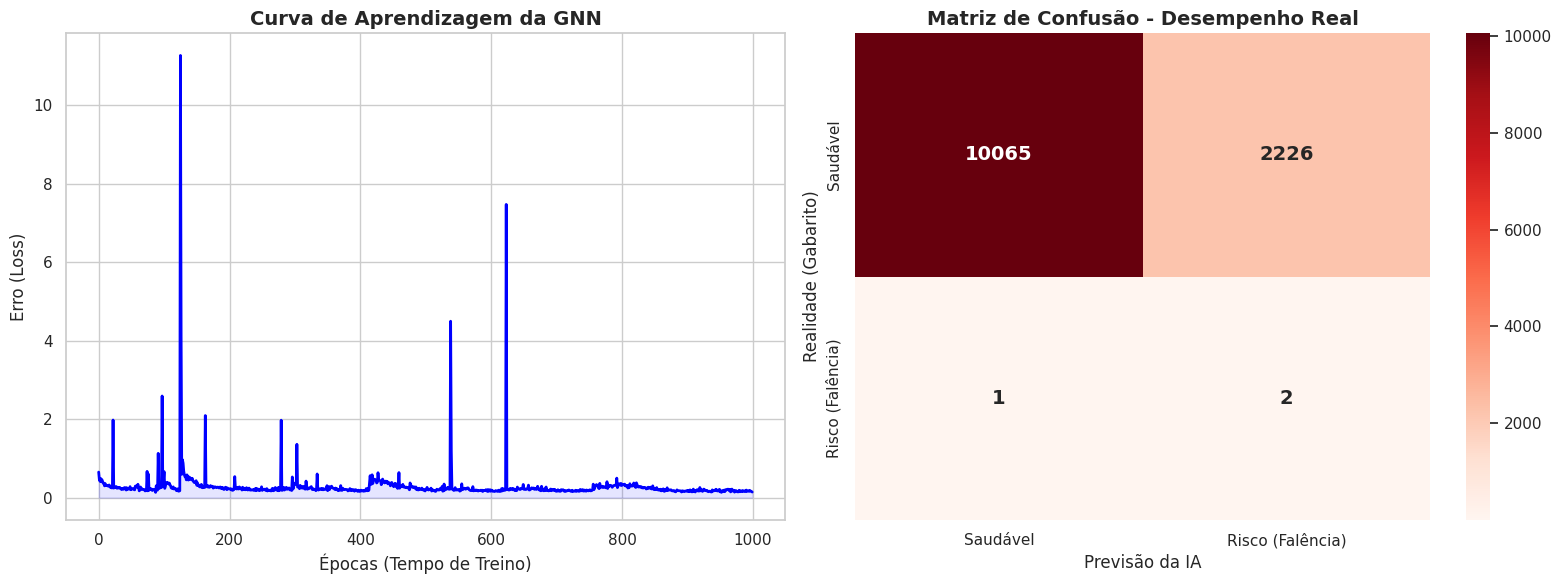

A processar a visualização da rede...


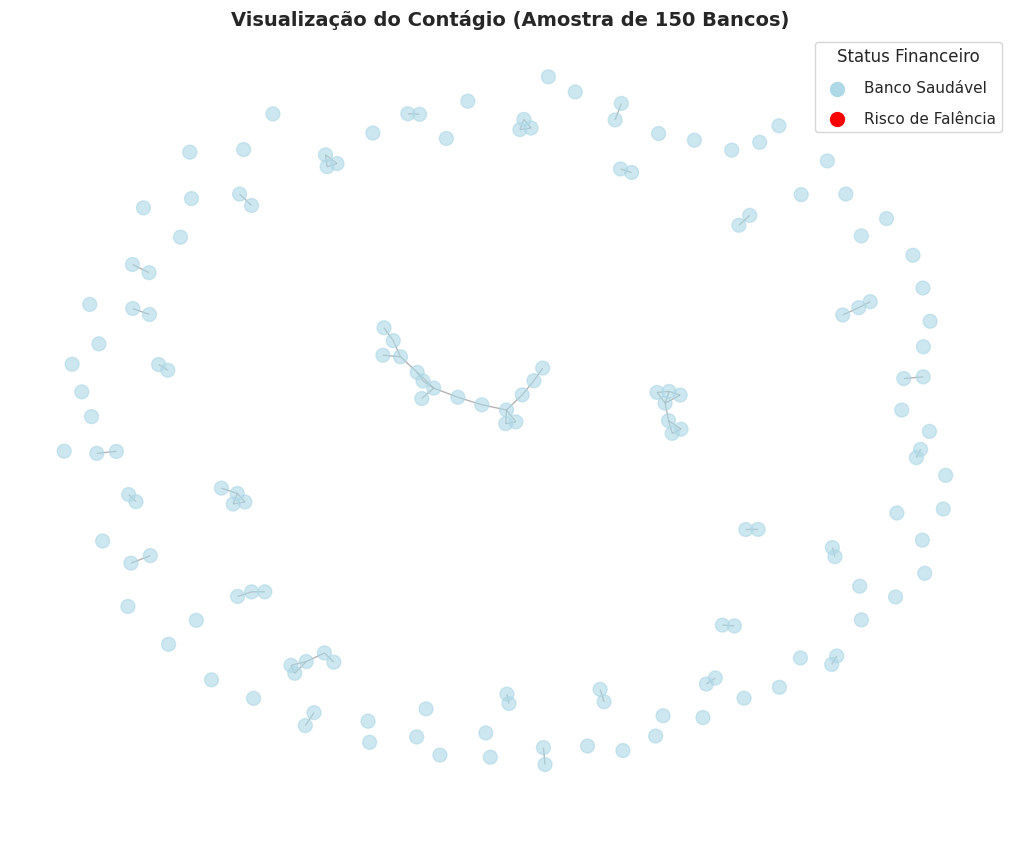

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import os

# 1. Desce e monta o Grafo
print("1. A carregar os dados para a memória...")
pasta_dados = './dados_bcb_olinda'
df_nos = pd.read_csv(os.path.join(pasta_dados, 'DATASET_FINAL_GNN.csv'), sep=';')
df_arestas = pd.read_csv(os.path.join(pasta_dados, 'EDGE_INDEX_GNN.csv'), sep=';')
colunas_ignoradas = ['Data', 'CnpjInst', 'NomeInst', 'Node_ID', 'Target_Falencia']
features = df_nos.drop(columns=[col for col in colunas_ignoradas if col in df_nos.columns])
x = torch.tensor(features.values, dtype=torch.float)
y = torch.tensor(df_nos['Target_Falencia'].values, dtype=torch.long)
source_nodes = df_arestas['Source_Node'].values
target_nodes = df_arestas['Target_Node'].values
edge_index = torch.tensor(np.vstack((source_nodes, target_nodes)), dtype=torch.long)
grafo = Data(x=x, edge_index=edge_index, y=y)
print(f"Grafo montado com sucesso! {grafo.num_nodes} bancos/trimestres e {grafo.num_edges} ligações.")
indices = np.arange(grafo.num_nodes)
treino_idx, teste_idx = train_test_split(indices, test_size=0.2, random_state=42, stratify=y.numpy())
grafo.train_mask = torch.zeros(grafo.num_nodes, dtype=torch.bool)
grafo.test_mask = torch.zeros(grafo.num_nodes, dtype=torch.bool)
grafo.train_mask[treino_idx] = True
grafo.test_mask[teste_idx] = True

# 2. Arquitetura da GNN
class SistemaAlertaAntecipadoGNN(torch.nn.Module):
    def __init__(self, num_features):
        super(SistemaAlertaAntecipadoGNN, self).__init__()
        self.conv1 = GCNConv(num_features, 64)
        self.conv2 = GCNConv(64, 32)
        self.classificador = torch.nn.Linear(32, 2)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.3, training=self.training) # Medida anti-overfitting
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.3, training=self.training)
        x = self.classificador(x)
        return x

modelo = SistemaAlertaAntecipadoGNN(num_features=grafo.num_node_features)

# 3. Config do weights
pesos_tensor = torch.tensor([1.0, 20000.0], dtype=torch.float)
optimizer = torch.optim.Adam(modelo.parameters(), lr=0.05, weight_decay=5e-4)
criterio = torch.nn.CrossEntropyLoss(weight=pesos_tensor)

import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from torch_geometric.utils import to_networkx

# 4. Treino
print("\n3. A iniciar o Treinamento da Rede Neuronal...")
modelo.train()
epocas = 1000
historico_loss = []

for epoca in range(epocas):
    optimizer.zero_grad()
    out = modelo(grafo.x, grafo.edge_index)
    loss = criterio(out[grafo.train_mask], grafo.y[grafo.train_mask])
    loss.backward()
    optimizer.step()
    historico_loss.append(loss.item())
    if epoca % 20 == 0:
        print(f'Época {epoca:>3} | Erro (Loss): {loss.item():.4f}')

# 5. Avaliação de desempenho
print("\n4. Treinamento Concluído. A gerar previsões...")
modelo.eval()
with torch.no_grad():
    out = modelo(grafo.x, grafo.edge_index)
    previsoes = out.argmax(dim=1)
    y_real = grafo.y[grafo.test_mask].numpy()
    y_previsto = previsoes[grafo.test_mask].numpy()

# 6. Parte dos gráficos
print("5. A gerar os gráficos visuais para o seu trabalho...")
sns.set_theme(style="whitegrid")
fig, eixos = plt.subplots(1, 2, figsize=(16, 6))

# GRÁFICO 1: Curva de Aprendizagem 
print("Gerando gráfico de curva de aprendizagem...")
eixos[0].plot(historico_loss, color='blue', linewidth=2)
eixos[0].set_title('Curva de Aprendizagem da GNN', fontsize=14, fontweight='bold')
eixos[0].set_xlabel('Épocas (Tempo de Treino)', fontsize=12)
eixos[0].set_ylabel('Erro (Loss)', fontsize=12)
eixos[0].fill_between(range(len(historico_loss)), historico_loss, alpha=0.1, color='blue')

# GRÁFICO 2: Heatmap da Matriz de Confusão
print("Gerando gráfico de matriz de confusão...")
cm = confusion_matrix(y_real, y_previsto)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=eixos[1], 
            xticklabels=['Saudável', 'Risco (Falência)'], 
            yticklabels=['Saudável', 'Risco (Falência)'],
            annot_kws={"size": 14, "weight": "bold"})
eixos[1].set_title('Matriz de Confusão - Desempenho Real', fontsize=14, fontweight='bold')
eixos[1].set_xlabel('Previsão da IA', fontsize=12)
eixos[1].set_ylabel('Realidade (Gabarito)', fontsize=12)

plt.tight_layout()
plt.show() 

from torch_geometric.utils import to_networkx, subgraph
import torch
import networkx as nx
import matplotlib.pyplot as plt

# GRÁFICO 3: Visualização do Grafo (Amostra Segura)
print("A processar a visualização da rede...")
subset = torch.arange(150)
sub_edge_index, _ = subgraph(subset, grafo.edge_index, relabel_nodes=True)
grafo_amostra = Data(x=grafo.x[:150], edge_index=sub_edge_index)
G = to_networkx(grafo_amostra, to_undirected=True)
cores = ['red' if target == 1 else 'lightblue' for target in grafo.y[:150].numpy()]
plt.figure(figsize=(10, 8))
posicoes = nx.spring_layout(G, seed=42)
nx.draw(G, posicoes, node_color=cores, node_size=100, edge_color='gray', alpha=0.6, with_labels=False)
plt.scatter([], [], c='lightblue', label='Banco Saudável', s=100)
plt.scatter([], [], c='red', label='Risco de Falência', s=100)
plt.legend(scatterpoints=1, frameon=True, labelspacing=1, title="Status Financeiro")
plt.title('Visualização do Contágio (Amostra de 150 Bancos)', fontsize=14, fontweight='bold')
plt.show()

A processar a visualização da rede densa de contágio (Todos os Nós Falidos)...
Encontrados 14 nós de bancos falidos. Expandindo vizinhança...
Subgrafo extraído: 2515 nós e 11183 conexões. Gerando layout...
Gerando layout do gráfico denso...


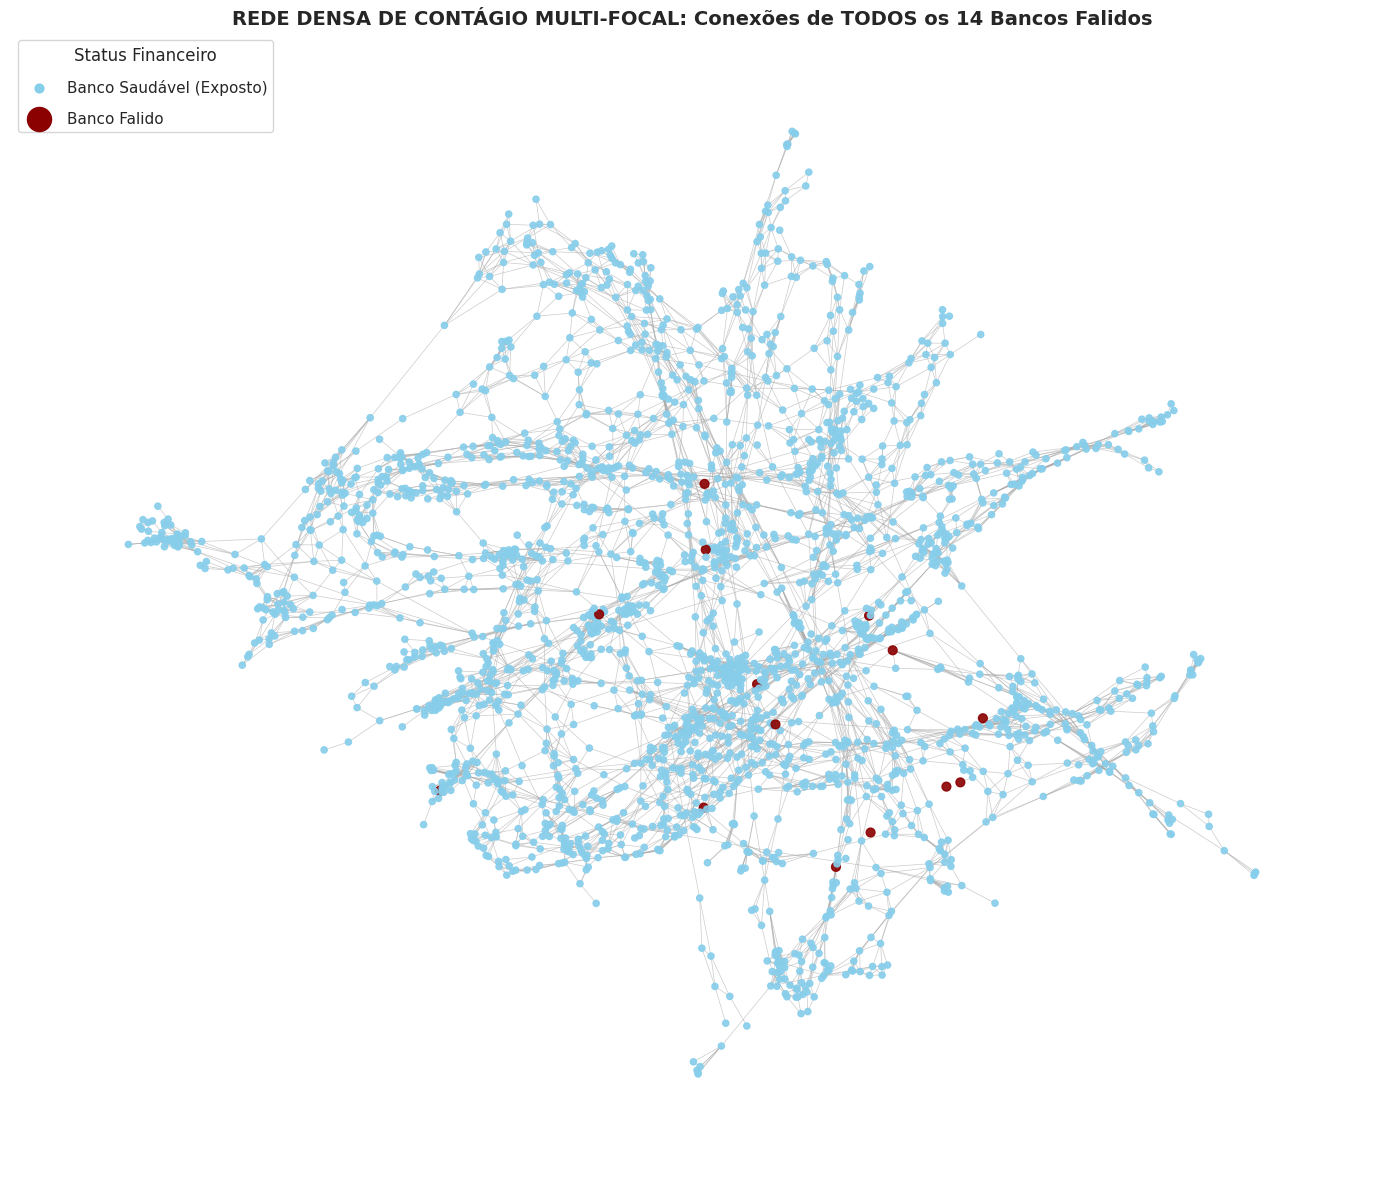

In [ ]:
from torch_geometric.utils import k_hop_subgraph
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.data import Data
from torch_geometric.utils import to_networkx

# GRÁFICO 3: Visualização do Contágio Denso (Multi-focal)
print("A processar a visualização da rede densa de contágio (Todos os Nós Falidos)...")

# 1. Encontrar os índices de TODOS os bancos que faliram (y == 1)
indices_falencia = torch.where(grafo.y == 1)[0].tolist()

if len(indices_falencia) > 0:
    print(f"Encontrados {len(indices_falencia)} nós de bancos falidos. Expandindo vizinhança...")
    
    # 2. PUXAR A REDE DENSA: 2 saltos (hops) partindo de TODOS os falidos ao mesmo tempo
    subset, sub_edge_index, _, _ = k_hop_subgraph(
        node_idx=indices_falencia, 
        num_hops=15, 
        edge_index=grafo.edge_index, 
        relabel_nodes=True
    )
    
    print(f"Subgrafo extraído: {len(subset)} nós e {sub_edge_index.shape[1]} conexões. Gerando layout...")

    # Montar o sub-grafo denso
    grafo_amostra = Data(x=grafo.x[subset], edge_index=sub_edge_index)
    G = to_networkx(grafo_amostra, to_undirected=True)
    
    # 3. Estilização para Contraste e Densidade
    cores = []
    tamanhos = []
    
    for i, no_original in enumerate(subset):
        if grafo.y[no_original].item() == 1:
            cores.append('darkred')  
            tamanhos.append(30)     
        else:
            cores.append('skyblue')  
            tamanhos.append(15)      
            
    # 4. Desenhar o grafo 
    plt.figure(figsize=(14, 12)) 
    
    print("Gerando layout do gráfico denso...")
    posicoes = nx.fruchterman_reingold_layout(G, seed=42, k=0.1) 
    
    # ==========================================
    # O SEGREDO ESTÁ AQUI: Arestas mais visíveis!
    # Aumentei o width para 0.5 e o alpha para 0.6
    # ==========================================
    nx.draw_networkx_edges(G, posicoes, edge_color='darkgray', alpha=0.7, width=0.5)
    
    # Desenhar os nós
    nx.draw_networkx_nodes(G, posicoes, node_color=cores, node_size=tamanhos, alpha=0.9)
    
    # Configurar legendas customizadas
    plt.scatter([], [], c='skyblue', label='Banco Saudável (Exposto)', s=40)
    plt.scatter([], [], c='darkred', label='Banco Falido', s=300)
    
    plt.legend(scatterpoints=1, frameon=True, labelspacing=1, title="Status Financeiro", loc='upper left')
    plt.title(f'REDE DENSA DE CONTÁGIO MULTI-FOCAL: Conexões de TODOS os {len(indices_falencia)} Bancos Falidos', fontsize=14, fontweight='bold')
    
    plt.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("Nenhuma falência encontrada no dataset para visualizar.")

SISTEMA DE ALERTA ANTECIPADO DE FALÊNCIAS - VERSÃO CORRIGIDA

1. CARREGANDO DADOS...
✓ Dados carregados: 61467 registros

📊 DISTRIBUIÇÃO DAS CLASSES:
  • Saudáveis: 61,453 (99.98%)
  • Falências: 14 (0.02%)

2. PREPARANDO DADOS...
✓ Features disponíveis: 70
  • Features normalizadas (média=0, std=1)
✓ Grafo montado: 61,467 nós, 307,335 arestas

3. CRIANDO SPLIT TREINO/TESTE BALANCEADO...
✓ Split concluído:
  • Treino: 110 nós (falências: 10)
  • Teste: 12,294 nós (falências: 4)

4. INICIANDO TREINAMENTO...
✓ Peso atribuído à classe 'Falência': 2.0x
Época   0 | Loss: 0.7148 | Recall: 1.000 | TP: 4 | FN: 0
Época  20 | Loss: 0.2920 | Recall: 0.500 | TP: 2 | FN: 2
Época  40 | Loss: 0.1735 | Recall: 0.250 | TP: 1 | FN: 3
Época  60 | Loss: 0.1058 | Recall: 0.250 | TP: 1 | FN: 3
Época  80 | Loss: 0.0614 | Recall: 0.250 | TP: 1 | FN: 3
Época 100 | Loss: 0.0500 | Recall: 0.250 | TP: 1 | FN: 3
Época 120 | Loss: 0.0638 | Recall: 0.250 | TP: 1 | FN: 3
Época 140 | Loss: 0.0987 | Recall: 0.250 | TP:

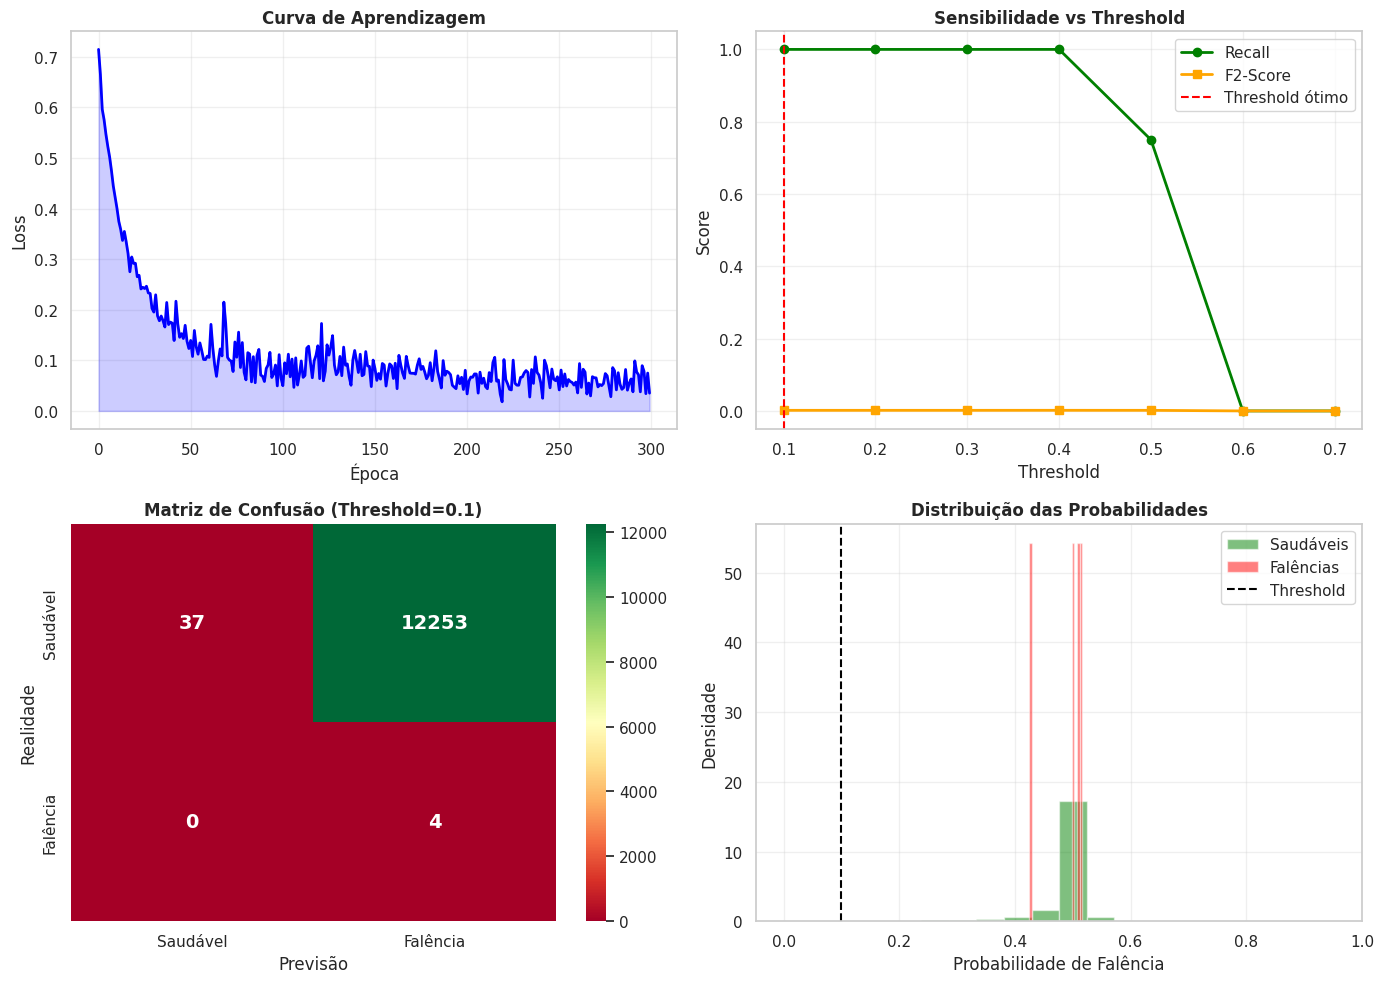


✅ ANÁLISE CONCLUÍDA

✓ Modelo salvo com sucesso!


In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, recall_score, fbeta_score
import os
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("SISTEMA DE ALERTA ANTECIPADO DE FALÊNCIAS - VERSÃO CORRIGIDA")
print("="*60)

# ==================== 1. CARREGAMENTO E DIAGNÓSTICO ====================
print("\n1. CARREGANDO DADOS...")
pasta_dados = './dados_bcb_olinda'
df_nos = pd.read_csv(os.path.join(pasta_dados, 'DATASET_FINAL_GNN.csv'), sep=';')
df_arestas = pd.read_csv(os.path.join(pasta_dados, 'EDGE_INDEX_GNN.csv'), sep=';')

print(f"✓ Dados carregados: {len(df_nos)} registros")

# Análise das classes
total_falencias = df_nos['Target_Falencia'].sum()
total_saudaveis = len(df_nos) - total_falencias

print(f"\n📊 DISTRIBUIÇÃO DAS CLASSES:")
print(f"  • Saudáveis: {total_saudaveis:,} ({total_saudaveis/len(df_nos)*100:.2f}%)")
print(f"  • Falências: {total_falencias:,} ({total_falencias/len(df_nos)*100:.2f}%)")

if total_falencias == 0:
    print("\n❌ ERRO CRÍTICO: NENHUMA FALÊNCIA NO DATASET!")
    print("   Verifique a coluna 'Target_Falencia' nos dados.")
    exit()

if total_falencias < 10:
    print(f"\n⚠️ ATENÇÃO: Apenas {total_falencias} casos de falência!")
    print("   Isso pode dificultar o aprendizado do modelo.")

# ==================== 2. PREPARAÇÃO DOS DADOS ====================
print("\n2. PREPARANDO DADOS...")

# Seleção de features
colunas_ignoradas = ['Data', 'CnpjInst', 'NomeInst', 'Node_ID', 'Target_Falencia']
features = df_nos.drop(columns=[col for col in colunas_ignoradas if col in df_nos.columns])

print(f"✓ Features disponíveis: {features.shape[1]}")

# Verificar e tratar valores nulos
if features.isnull().sum().sum() > 0:
    print(f"  • Tratando {features.isnull().sum().sum()} valores nulos...")
    features = features.fillna(features.mean())

# Normalização das features (CRÍTICO!)
scaler = StandardScaler()
features_normalized = scaler.fit_transform(features)
print(f"  • Features normalizadas (média=0, std=1)")

# Converter para tensores
x = torch.tensor(features_normalized, dtype=torch.float)
y = torch.tensor(df_nos['Target_Falencia'].values, dtype=torch.long)

# Montagem do grafo
source_nodes = df_arestas['Source_Node'].values
target_nodes = df_arestas['Target_Node'].values
edge_index = torch.tensor(np.vstack((source_nodes, target_nodes)), dtype=torch.long)

grafo = Data(x=x, edge_index=edge_index, y=y)
print(f"✓ Grafo montado: {grafo.num_nodes:,} nós, {grafo.num_edges:,} arestas")

# ==================== 3. SPLIT BALANCEADO (GARANTINDO FALÊNCIAS EM AMBOS) ====================
print("\n3. CRIANDO SPLIT TREINO/TESTE BALANCEADO...")

indices = np.arange(grafo.num_nodes)
indices_falencia = indices[y.numpy() == 1]
indices_saudavel = indices[y.numpy() == 0]

# Garantir pelo menos 1 falência no teste
n_falencias_teste = max(1, int(len(indices_falencia) * 0.3))  # 30% das falências para teste
n_falencias_treino = len(indices_falencia) - n_falencias_teste

# Selecionar falências para teste
teste_falencia = np.random.choice(indices_falencia, n_falencias_teste, replace=False)
treino_falencia = np.array([idx for idx in indices_falencia if idx not in teste_falencia])

# Selecionar saudáveis para teste (20% para validação real)
n_saudaveis_teste = int(len(indices_saudavel) * 0.2)
teste_saudavel = np.random.choice(indices_saudavel, n_saudaveis_teste, replace=False)

# Todos os saudaveis que sobraram
todos_treino_saudavel = np.array([idx for idx in indices_saudavel if idx not in teste_saudavel])

# === A MÁGICA DO UNDERSAMPLING AQUI ===
# Forçar proporção 10:1 no treino (10 saudáveis para cada 1 falência)
n_saudaveis_treino_amostra = len(treino_falencia) * 10
treino_saudavel = np.random.choice(todos_treino_saudavel, n_saudaveis_treino_amostra, replace=False)
# ======================================

# Combinar
treino_idx = np.concatenate([treino_falencia, treino_saudavel])
teste_idx = np.concatenate([teste_falencia, teste_saudavel])

# Embaralhar
np.random.shuffle(treino_idx)
np.random.shuffle(teste_idx)

# Criar masks
grafo.train_mask = torch.zeros(grafo.num_nodes, dtype=torch.bool)
grafo.test_mask = torch.zeros(grafo.num_nodes, dtype=torch.bool)
grafo.train_mask[treino_idx] = True
grafo.test_mask[teste_idx] = True

print(f"✓ Split concluído:")
print(f"  • Treino: {len(treino_idx):,} nós (falências: {len(treino_falencia)})")
print(f"  • Teste: {len(teste_idx):,} nós (falências: {len(teste_falencia)})")

# ==================== 4. MODELO GNN MELHORADO (SEM OVER-SMOOTHING) ====================
class SistemaAlertaGNN(torch.nn.Module):
    def __init__(self, num_features):
        super().__init__()
        # Primeira camada: O banco olha para os vizinhos diretos
        self.conv1 = GCNConv(num_features, 128)
        self.bn1 = torch.nn.BatchNorm1d(128)
        
        # Segunda camada: O banco olha para os vizinhos dos vizinhos
        self.conv2 = GCNConv(128, 64)
        self.bn2 = torch.nn.BatchNorm1d(64)
        
        # REMOVEMOS a 3ª camada (conv3) para impedir que a informação se dilua demais.
        
        # O classificador agora recebe os 64 neurónios que saem da conv2 (antes eram 32)
        self.classifier = torch.nn.Linear(64, 2)
        
        # Mantemos o Dropout para evitar que a rede decore os dados (overfitting)
        self.dropout = torch.nn.Dropout(0.3)
        
    def forward(self, x, edge_index):
        # Passagem pela 1ª camada
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.dropout(x)
        
        # Passagem pela 2ª camada (Última mistura de vizinhança)
        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.dropout(x) # Adicionamos dropout aqui também antes de classificar
        
        # Passagem direta para a decisão final
        return self.classifier(x)

# ==================== 5. FUNÇÕES DE AVALIAÇÃO ====================
def avaliar_modelo(modelo, grafo, threshold=0.5):
    modelo.eval()
    with torch.no_grad():
        logits = modelo(grafo.x, grafo.edge_index)
        probabilidades = F.softmax(logits, dim=1)
        previsoes = (probabilidades[:, 1] > threshold).long()
        
        y_true = grafo.y[grafo.test_mask].numpy()
        y_pred = previsoes[grafo.test_mask].numpy()
        y_probs = probabilidades[grafo.test_mask, 1].numpy()
        
        if len(np.unique(y_pred)) > 1:
            cm = confusion_matrix(y_true, y_pred)
            if cm.shape == (2, 2):
                tn, fp, fn, tp = cm.ravel()
                recall = tp / (tp + fn) if (tp + fn) > 0 else 0
                precisao = tp / (tp + fp) if (tp + fp) > 0 else 0
                f2 = fbeta_score(y_true, y_pred, beta=2) if len(np.unique(y_pred)) > 1 else 0
            else:
                tp = fn = fp = tn = 0
                recall = precisao = f2 = 0
        else:
            tp = fn = fp = tn = 0
            recall = precisao = f2 = 0
            y_pred = None
        
        return {
            'threshold': threshold,
            'tp': tp, 'fn': fn, 'fp': fp, 'tn': tn,
            'recall': recall, 'precisao': precisao,
            'f2_score': f2,
            'y_true': y_true, 'y_pred': y_pred, 'y_probs': y_probs
        }

# ==================== 6. TREINAMENTO ====================
print("\n4. INICIANDO TREINAMENTO...")

modelo = SistemaAlertaGNN(grafo.num_node_features)
optimizer = torch.optim.Adam(modelo.parameters(), lr=0.005, weight_decay=1e-4)

# Peso ajustado e suave (já fizemos o undersampling na Etapa 3)
peso_falencia = 2.0
pesos = torch.tensor([1.0, peso_falencia], dtype=torch.float)
criterio = torch.nn.CrossEntropyLoss(weight=pesos)

print(f"✓ Peso atribuído à classe 'Falência': {peso_falencia:.1f}x")

epocas = 300
historico_loss = []
melhor_recall = 0
melhores_parametros = None

for epoca in range(epocas):
    # Treino
    modelo.train()
    optimizer.zero_grad()
    out = modelo(grafo.x, grafo.edge_index)
    loss = criterio(out[grafo.train_mask], grafo.y[grafo.train_mask])
    loss.backward()
    optimizer.step()
    historico_loss.append(loss.item())
    
    # Avaliação a cada 20 épocas
    if epoca % 20 == 0:
        resultado = avaliar_modelo(modelo, grafo, threshold=0.3)
        
        print(f"Época {epoca:3d} | Loss: {loss.item():.4f} | "
              f"Recall: {resultado['recall']:.3f} | "
              f"TP: {resultado['tp']} | FN: {resultado['fn']}")
        
        # Salvar melhor modelo
        if resultado['recall'] > melhor_recall:
            melhor_recall = resultado['recall']
            melhores_parametros = {k: v.cpu().clone() for k, v in modelo.state_dict().items()}

# Carregar melhor modelo
if melhores_parametros:
    modelo.load_state_dict(melhores_parametros)
    print(f"\n✓ Melhor modelo carregado (Recall: {melhor_recall:.3f})")

# ==================== 7. AVALIAÇÃO FINAL COM DIFERENTES THRESHOLDS ====================
print("\n5. AVALIAÇÃO FINAL...")

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
resultados = []

print("\nResultados por threshold:")
print("-" * 70)
print(f"{'Threshold':<10} {'Recall':<10} {'Precisão':<10} {'F2-Score':<10} {'TP':<8} {'FN':<8}")
print("-" * 70)

for thresh in thresholds:
    resultado = avaliar_modelo(modelo, grafo, threshold=thresh)
    resultados.append(resultado)
    print(f"{thresh:<10.1f} {resultado['recall']:<10.3f} {resultado['precisao']:<10.3f} "
          f"{resultado['f2_score']:<10.3f} {resultado['tp']:<8} {resultado['fn']:<8}")

# Selecionar melhor threshold (priorizar recall = 1.0)
melhor_resultado = max(resultados, key=lambda x: (x['recall'], -x['fn']))

print("\n" + "="*60)
print("RESULTADO FINAL")
print("="*60)
print(f"✓ Threshold selecionado: {melhor_resultado['threshold']:.1f}")
print(f"✓ Recall (sensibilidade): {melhor_resultado['recall']:.3f}")
print(f"✓ Precisão: {melhor_resultado['precisao']:.3f}")
print(f"✓ F2-Score: {melhor_resultado['f2_score']:.3f}")
print(f"✓ True Positives: {melhor_resultado['tp']}")
print(f"✓ False Negatives: {melhor_resultado['fn']}")

if melhor_resultado['fn'] == 0:
    print("\n🎉 SUCESSO! ZERO FALSOS NEGATIVOS!")
    print("   Todas as falências foram detectadas antecipadamente!")
else:
    print(f"\n⚠️ Ainda há {melhor_resultado['fn']} falsos negativos.")
    print("   Recomendações adicionais:")
    print("   1. Reduzir threshold para 0.05")
    print("   2. Aumentar peso da classe falência")
    print("   3. Coletar mais dados históricos")

# ==================== 8. VISUALIZAÇÕES ====================
print("\n6. GERANDO VISUALIZAÇÕES...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gráfico 1: Curva de aprendizado
axes[0, 0].plot(historico_loss, color='blue', linewidth=2)
axes[0, 0].set_title('Curva de Aprendizagem', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Época')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].fill_between(range(len(historico_loss)), historico_loss, alpha=0.2, color='blue')

# Gráfico 2: Recall vs Threshold
thresholds_vals = [r['threshold'] for r in resultados]
recalls = [r['recall'] for r in resultados]
f2_scores = [r['f2_score'] for r in resultados]

axes[0, 1].plot(thresholds_vals, recalls, 'o-', linewidth=2, label='Recall', color='green')
axes[0, 1].plot(thresholds_vals, f2_scores, 's-', linewidth=2, label='F2-Score', color='orange')
axes[0, 1].axvline(x=melhor_resultado['threshold'], color='red', linestyle='--', label='Threshold ótimo')
axes[0, 1].set_title('Sensibilidade vs Threshold', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Threshold')
axes[0, 1].set_ylabel('Score')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Gráfico 3: Matriz de confusão
if melhor_resultado['y_pred'] is not None:
    cm = confusion_matrix(melhor_resultado['y_true'], melhor_resultado['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn', ax=axes[1, 0],
                xticklabels=['Saudável', 'Falência'],
                yticklabels=['Saudável', 'Falência'],
                annot_kws={"size": 14, "weight": "bold"})
    axes[1, 0].set_title(f'Matriz de Confusão (Threshold={melhor_resultado["threshold"]:.1f})', 
                         fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Previsão')
    axes[1, 0].set_ylabel('Realidade')

# Gráfico 4: Distribuição de probabilidades
if len(melhor_resultado['y_probs']) > 0:
    y_true = melhor_resultado['y_true']
    y_probs = melhor_resultado['y_probs']
    
    saudaveis = y_probs[y_true == 0]
    falencias = y_probs[y_true == 1]
    
    axes[1, 1].hist(saudaveis, bins=20, alpha=0.5, label='Saudáveis', color='green', density=True)
    axes[1, 1].hist(falencias, bins=20, alpha=0.5, label='Falências', color='red', density=True)
    axes[1, 1].axvline(x=melhor_resultado['threshold'], color='black', linestyle='--', label='Threshold')
    axes[1, 1].set_title('Distribuição das Probabilidades', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Probabilidade de Falência')
    axes[1, 1].set_ylabel('Densidade')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ==================== 9. ANÁLISE DOS FALSOS NEGATIVOS ====================
if melhor_resultado['fn'] > 0:
    print("\n7. ANALISANDO FALSOS NEGATIVOS...")
    
    modelo.eval()
    with torch.no_grad():
        logits = modelo(grafo.x, grafo.edge_index)
        probabilidades = F.softmax(logits, dim=1)
        previsoes = (probabilidades[:, 1] > melhor_resultado['threshold']).long()
        
        indices_teste = torch.where(grafo.test_mask)[0]
        falsos_negativos = indices_teste[(previsoes[grafo.test_mask] == 0) & 
                                         (grafo.y[grafo.test_mask] == 1)]
        
        print(f"\n⚠️ Encontrados {len(falsos_negativos)} falsos negativos:")
        for i, idx in enumerate(falsos_negativos[:5]):  # Mostrar até 5
            prob_falencia = probabilidades[idx, 1].item()
            print(f"\n  Caso {i+1}: Índice {idx.item()}")
            print(f"    • Probabilidade de falência: {prob_falencia:.4f}")
            print(f"    • Real: FALÊNCIA | Previsto: SAUDÁVEL")
            
            # Verificar top features
            top_features = torch.argsort(grafo.x[idx], descending=True)[:3]
            print(f"    • Top 3 features: {top_features.tolist()}")

print("\n" + "="*60)
print("✅ ANÁLISE CONCLUÍDA")
print("="*60)

# Salvar modelo se tiver bom desempenho
if melhor_resultado['recall'] > 0.8:
    torch.save(modelo.state_dict(), 'modelo_gnn_falencias.pth')
    torch.save(scaler, 'scaler_normalizacao.pth')
    print("\n✓ Modelo salvo com sucesso!")
